In [1]:
# this script prepares individual datasets. Preparation involves:
# for ERA5 data:
#   - calculating zonal average for provinces
#   - calculating SPI6 based on zonal average
# for ECMWF SEAS5.1 forecast:
#   - calculating zonal average for provinces
#   - calculating probability of below normal rainfall for each forecast based on quantiles of overall forecast distribution 
#      with distribution determined separately for each initialization month and each lead time
# for MODIS LST:
#   - calcuating zonal average for provinces



# processing requires a few libraries - these have to be installed in advance into the python environment
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import os, sys, glob
import rioxarray

import cartopy.crs as ccrs
from datetime import datetime
from rasterstats import zonal_stats
from rasterio.enums import Resampling


# this is a library obtained from drought.gov, code is unchanged, but since the library is originally 
# intended to be used as a command line tool, I just extracted functions that are required to calculate SPI
# and attached them to this set of scripts as a loadable python library
from climate_indices import indices, compute

#this library is used to derive zonal averages. It has to be installed using pip
#import xesmf as xe

#helper functions
def zonalmean(_grid, _poly,_namecolumn):
    affine=_grid.rio.transform()
    _zonalmean=[]
    for i in range(_grid.shape[0]):
        zs=zonal_stats(_poly, _grid[i,:,:].data, affine=affine, nodata=np.nan)
        temp=[x["mean"] for x in zs]
        _zonalmean.append(temp)

    _zonalmean=np.array(_zonalmean)
    _zonalmean=pd.DataFrame(_zonalmean, index=_grid.time, columns=_poly[_namecolumn])
    return(_zonalmean)


def calcspi(_prec, _scale,_dist,_freq,_fyear,_cfyear,_ceyear):
    dist={"gamma":indices.Distribution.gamma, "pearson":indices.Distribution.pearson}
    freq={"monthly":compute.Periodicity.monthly, "daily":compute.Periodicity.daily}
    _spi = indices.spi(_prec,  _scale, dist[_dist], _fyear, _cfyear, _ceyear,freq[_freq])
    return(_spi)

def spionpandas(_prec, _scale,_fyear,_cfyear,_ceyear,_freq="monthly",_dist="gamma"):
    _spipd=_prec.copy().astype("float64")
    for i in range(_spipd.shape[1]):
        regdata=calcspi(_prec.iloc[:,i].values,_scale,_dist,_freq,_fyear,_cfyear,_ceyear)
        _spipd.iloc[:,i]=regdata
    return(_spipd)

def droughtprob(_fcst,_obs):
#    print(_fcst.shape, _obs.shape)
    n=(~np.isnan(_fcst)).sum(1)
    count=np.sum(_fcst<_obs.reshape(-1,1), axis=1)
#    print(count[0], n[0])
    return(np.array(count/n*100).reshape(1,-1)) 

In [2]:
#shapefile with provinces
studyarea = gpd.read_file("../data/gis/study_area.shp")
studyregions=studyarea["NAME_1"]

zonaldir="./data/zonal_data/"

# extracting ERA5 rainfall for zones and calculating SPI6

In [6]:
datadir="./data/ERA5_rainfall"
spitimescale=6

ds=xr.open_mfdataset(f"{datadir}/tp_*.nc")

ds=ds.compute()

#converting variable names
data=ds.rename({"tp":"PRCPTOT", "valid_time":"time"})

#dropping unnecessary variables
data=data.drop_vars("expver")
data=data.drop_vars("number")

#cleaning up
data=data.sortby("time")
data=data.sortby("latitude", ascending=False)

#checking first and last available date
firstdate=pd.to_datetime(data.time.data[0])
lastdate=pd.to_datetime(data.time.data[-1])

print(f"data available for {firstdate} to {lastdate}")

#converting from m3/m2/s to mm/month
data=data*1000*30.15

#forcing data into memory
da=data["PRCPTOT"].compute()


data available for 1980-01-01 06:00:00 to 2026-03-01 06:00:00


In [5]:
#this library is used to derive zonal averages. It has to be installed using pip
import xesmf as xe


/home/piotr/mambaforge/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


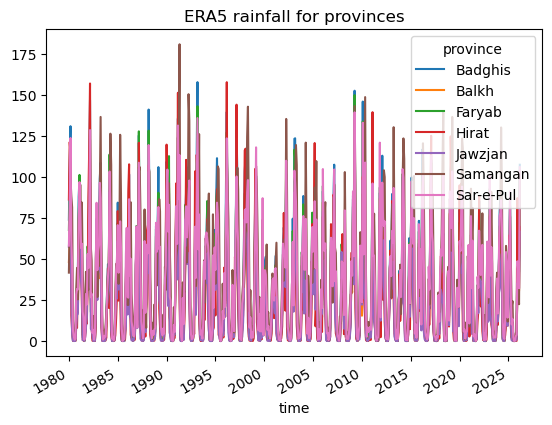

<Axes: title={'center': 'SPI6 based on ERA5'}, xlabel='time'>

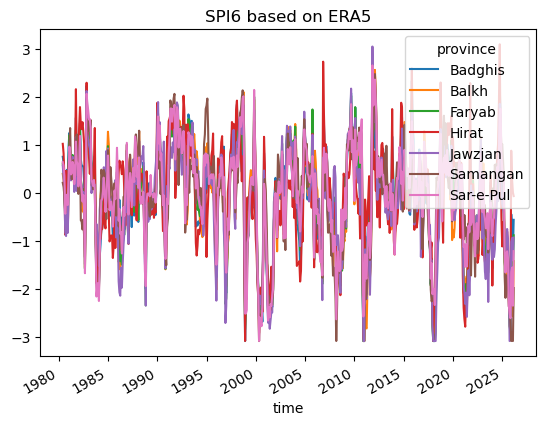

In [11]:
#calculating zonal means
#deriving weights
savg = xe.SpatialAverager(da[0,:], studyarea.geometry, geom_dim_name="NAME_1")

pr_era5_zm=savg(da)

pr_era5_zm=pr_era5_zm.rename({"NAME_1":"province"})

#adding province names 
pr_era5_zm["province"]=studyarea["NAME_1"]

#converting to pandas
pr_era5_zm=pr_era5_zm.to_pandas()

#saving file
#pr_era5_zm.to_csv("{}/PRCPTOT_era5_{}-{}.csv".format(zonaldir, firstdate.strftime("%Y%m"), lastdate.strftime("%Y%m")))

## calculating SPI
spi6_era5=spionpandas(pr_era5_zm, spitimescale,1981,1981,2010)

spi6_era5.to_csv("{}/spi{}_mon_era5_{}-{}.csv".format(zonaldir, spitimescale, firstdate.strftime("%Y%m"), lastdate.strftime("%Y%m")))


#plotting output
pr_era5_zm.plot(title="ERA5 rainfall for provinces")
plt.show()

spi6_era5.plot(title='SPI6 based on ERA5')

# Processing ECMWF forecast to derive forecast probability of drought

In [3]:
#this is where forecast data are going to be read from
datadir="./data/SEAS51_rainfall/"

In [7]:
#ECMWF forecast

#this is variable that will be read from netcdf files
var="pr"

# grid of the forecast changes in Feb 2025, thus data need to be resampled


#define target grid
lats = np.arange(41,25,-1)
lons = np.arange(60, 71, 1)

ds_target = xr.Dataset(coords={"lat": lats, "lon": lons})
ds_target = ds_target.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
ds_target = ds_target.rio.write_crs("EPSG:4326")


#opening and resampling each file
alldata=[]
files=glob.glob("{}/pr_mon_ECMWF_SEAS51_*.nc".format(datadir))
for file in files:
    #print(file)
    ds=xr.open_dataset(file)
    ds = ds.rio.write_crs("EPSG:4326")
    ds=ds.rename({"forecastMonth":"leadtime", "forecast_reference_time":"time", 'number':"member", "tprate":"pr"})
    ds_regridded=[]
    for i in range(ds.time.size):
        fcstleadtime=[]
        for j in range(ds.leadtime.size):
            fcst=ds.isel(time=i,leadtime=j).rio.reproject_match(ds_target,resampling=Resampling.bilinear)
            fcstleadtime.append(fcst)
        ds_regridded.append(xr.concat(fcstleadtime, dim="leadtime"))
    alldata.append(xr.concat(ds_regridded, dim="time").rename({"x":"longitude","y":"latitude"}))

    
#concatenating data
data=xr.concat(alldata, dim="time")

#making sure it is in the correct sequence - time and variable sequence
data=data.sortby("time")
data=data.transpose("time","leadtime","member","latitude","longitude")

#substituting the original leadtime with one that starts with 0 for the month of the forecast
data["leadtime"]=data.leadtime-1

#converting rainfall rate to mm/month
data=data*86400*30.15*1000

#calculating zonal average using xesmf library
#deriving weights
savg = xe.SpatialAverager(data[var][0,0,0,:,:], studyarea.geometry, geom_dim_name="NAME_1")

#applying weights
pr_seas51_zm=savg(data["pr"])
pr_seas51_zm=pr_seas51_zm.rename({"NAME_1":"province"})

#adding province names 
pr_seas51_zm["province"]=studyarea["NAME_1"]

#rolling average to derive seasonal totals
pr_seas51_zm=pr_seas51_zm.rolling(leadtime=3).mean()

#selecting only months with valid data
pr_seas51_zm=pr_seas51_zm.sel(leadtime=slice(2,6))

#converting to xarray dataset
pr_seas51_zm=pr_seas51_zm.to_dataset(name="pr")


#shifting time to target time - the resulting data array gives data forecasted for a given time 
# with a given lead time. Target time is the last month of the three-month season
targetdata=[]
for lt in pr_seas51_zm.leadtime:
    dat=pr_seas51_zm.sel(leadtime=slice(lt,lt))
    targetdate=pd.to_datetime(dat.time)+pd.offsets.MonthBegin(lt)
    dat["time"]=targetdate
    targetdata.append(dat)
fcst=xr.concat(targetdata, dim="leadtime")
#fcst time is target time, i.e. last month of the three months target season


#calculating forecasted probability of drought
# first - deriving "observed" 33rd quantile. Since we are not doing any bias correction or calibration, 
# it is derived from forecast by grouping all forecast data by month, and calculating from distribution of all monthly values
# reducing with member,time gives quantiles separately for each leadtime, thus allowing for 
# distributions to be slightly different at each leadtime

terc=33
monthly_q = fcst.groupby("time.month").reduce(np.nanquantile, q=terc/100, dim=["member", "time"])
month_idx = fcst['time.month']
result = monthly_q.sel(month=month_idx)
bnthreshold = result.assign_coords(time=fcst.time)

temp=xr.apply_ufunc(
    droughtprob, 
    fcst[var],
    bnthreshold[var],
    input_core_dims=[["time", "member"],["time"]],
    vectorize=True,
    output_core_dims=[["time"]]    
)

#cleaning up probability array
bnprob_fcst=temp.transpose("time","leadtime","province")
bnprob_fcst=bnprob_fcst.to_dataset(name="probability")

#checking dates for output file name 
firstdate=pr_seas51_zm.time.data[0]
lastdate=pr_seas51_zm.time.data[-1]

#saving data - this is a 3-D array, time, leadtime, province, so it is more convenient to keep it in xarray format
outputfile="./{}/droughtprob_mon_seas51_{}-{}.nc".format(zonaldir,pd.to_datetime(firstdate).strftime("%Y%m"), pd.to_datetime(lastdate).strftime("%Y%m"))
bnprob_fcst.to_netcdf(outputfile)

print("Saved","./{}/droughtprob_mon_seas51_{}-{}.nc".format(zonaldir,pd.to_datetime(firstdate).strftime("%Y%m"), pd.to_datetime(lastdate).strftime("%Y%m")))


Saved ././data/zonal_data//droughtprob_mon_seas51_198101-202604.nc


/tmp/ipykernel_507334/1725656596.py:69: RuntimeWarning: invalid value encountered in divide
  return(np.array(count/n*100).reshape(1,-1))


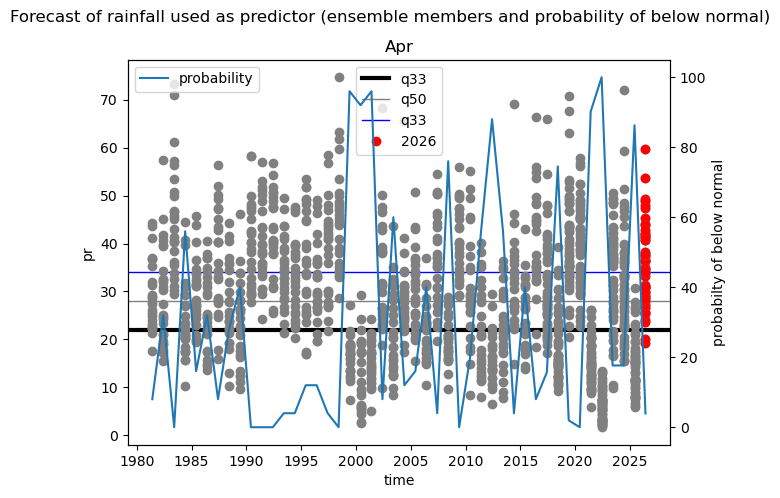

In [10]:
#this just plots individual ensemble members

months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
quarters=[1,1,1,2,2,2,3,3,3,4,4,4]
seasons={1:"NDJ",2:"DJF",3:"JFM",4:"FMA",5:"MAM",6:"AMJ",7:"MJJ",8:"JJA",9:"JAS",10:"ASO",11:"SON",12:"OND"}

#leadtime
lt=2
#year that will be highlingted
year="2026"
tgtmon=6

fig=plt.figure(figsize=(7,5))
pl=fig.add_subplot(1,1,1)    
data=fcst[var].sel(province="Faryab", leadtime=lt,time=fcst.time.dt.month==tgtmon)
quant=np.nanquantile(data,0.33)
plt.axhline(quant, color="black", linewidth=3, label="q33")
quant=np.nanquantile(data,0.5)
plt.axhline(quant, color="grey", linewidth=1, label="q50")
quant=np.nanquantile(data,0.66)
plt.axhline(quant, color="blue", linewidth=1, label="q33")

for member in fcst.member:
    data.sel(member=member).plot(linestyle="",marker="o",color="grey")
    dat=data.sel(member=member, time="{}-{}".format(year, str(tgtmon).zfill(2)))
    pl.plot(dat.time, dat.data, "o", color="red")
pl.plot(dat.time, dat.data, "o", color="red", label=year)
pl2=pl.twinx()
bnprob_fcst["probability"].sel(province="Faryab", leadtime=lt,time=fcst.time.dt.month==tgtmon).plot(ax=pl2, label="probability")        
pl.set_title("{}".format(months[tgtmon-3]))
pl2.set_title("")
pl2.set_ylabel("probabilty of below normal")

pl.legend()
pl2.legend()
plt.suptitle("Forecast of rainfall used as predictor (ensemble members and probability of below normal)")
plt.subplots_adjust(wspace=0.3)
plt.show()


# processing modis LST (MOD11C3)

In [16]:
#modis LST
# the pre 2025 January data were downloaded from a different source, 
# so processing is slightly different than that of post Jan2025 data

#downloaded from: https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/61/MOD11C3
    
#data will be read from here
datadir="./data/MODIS_LST"

#lst will be saved here
zonaldir="./data/zonal_data/"

#old data
data=xr.open_dataset("{}/MOD11C3.061.ncml.nc4".format(datadir))
n=data["LST_Day_CMG"].shape[0]
data=data.assign({"time":pd.date_range("2000-02-01", freq="MS", periods=n)})
data=data.rename({"LST_Day_CMG":"lst"})
data=data.rename({"Longitude":"longitude"})
data=data.rename({"Latitude":"latitude"})
olddata=data["lst"]
olddata=olddata.to_dataset(name="lst")


#update
import rioxarray as rxr
files=glob.glob("{}/MOD11C3.A*hdf".format(datadir))
newdata=[]
for file in np.sort(files):
    print(file)
    datestr=os.path.basename(file).split(".")[1][1:]
    date=datetime.strptime(datestr, "%Y%j")
    print(date)
    ds=rxr.open_rasterio(file)
    
    da=ds["LST_Day_CMG"]
    da=da.rename({"x":"longitude","y":"latitude", "band":"time"})
    da=da.sel(latitude=slice(38,32.45), longitude=slice(60,69.03))
    da["time"]=[date]
    ds.close()
    newdata.append(da)
newdata=xr.concat(newdata, dim="time")
newdata=newdata*0.02
newdata=newdata.to_dataset(name="lst")


newdata["latitude"]=newdata["latitude"].astype("float32")
newdata["longitude"]=newdata["longitude"].astype("float32")
olddata["latitude"]=olddata["latitude"].astype("float32")
olddata["longitude"]=olddata["longitude"].astype("float32")

#merging old and new
alldata=xr.concat([olddata, newdata], dim="time")

#calculating zonal mean
#ds=xr.open_dataset("../data/modis/lst_200001-202602.nc")
da=alldata["lst"]
da=da.rio.write_crs("epsg:4326")
lst_modis=zonalmean(da, studyarea, "NAME_1")

firstdate=da.time.data[0]
lastdate=da.time.data[-1]

outfile="{}/lst_modis_{}-{}.csv".format(zonaldir, pd.to_datetime(firstdate).strftime("%Y%m"), pd.to_datetime(lastdate).strftime("%Y%m"))
lst_modis.to_csv(outfile)
print("written ",outfile)

./data/MODIS_LST/MOD11C3.A2025060.061.2025093043031.hdf
2025-03-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025091.061.2025125142315.hdf
2025-04-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025121.061.2025153164905.hdf
2025-05-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025152.061.2025182145012.hdf
2025-06-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025182.061.2025213154157.hdf
2025-07-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025213.061.2025246014643.hdf
2025-08-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025244.061.2025275150152.hdf
2025-09-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025274.061.2025306143832.hdf
2025-10-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025305.061.2025335114103.hdf
2025-11-01 00:00:00
./data/MODIS_LST/MOD11C3.A2025335.061.2026006185449.hdf
2025-12-01 00:00:00
./data/MODIS_LST/MOD11C3.A2026001.061.2026034041909.hdf
2026-01-01 00:00:00
./data/MODIS_LST/MOD11C3.A2026032.061.2026062153720.hdf
2026-02-01 00:00:00
./data/MODIS_LST/MOD11C3.A2026060.061.2026091094145.hdf
2026-03-01 00:00:00
written  ./d

<Axes: title={'center': 'MODIS LST data'}>

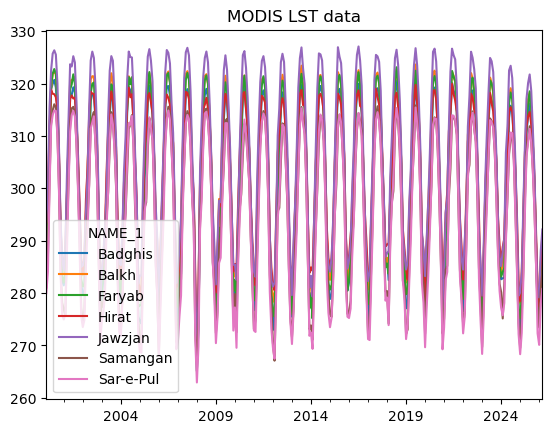

In [17]:
#plotting data
lst_modis.plot(title="MODIS LST data")